# Thompson-Konstruktion für reguläre Ausdrücke

Willkommen zum Workshop! In diesem Notebook lernst du, wie man die **Thompson-Konstruktion** implementiert. Das ist ein eleganter Algorithmus, der einen regulären Ausdruck (den wir zuerst in einen sogenannten AST - Abstract Syntax Tree - zerlegen) in einen nicht-deterministischen endlichen Automaten (NFA) verwandelt.

Keine Sorge, wenn du noch nie von Automaten gehört hast – wir gehen alles Schritt für Schritt durch. Wir nutzen zwei kleine Python-Pakete:
1. `ast_parser`: Liest deinen Regex-String und baut daraus einen Strukturbaum (AST).
2. `automaton`: Liefert uns die Bausteine für den Automaten (Zustände und Übergänge) und einen Executor, um zu testen, ob der Automat funktioniert.

In [1]:
!pip install graphviz
import sys
import graphviz
from dataclasses import dataclass
from ast_parser import RegexParser, regex_parsen, Literal, Concatenation, Alternation, ast_to_dot, UnaryOp
from automaton import State, NFA, nfa_to_dot
from regex import regex_test, regex_find

sys.path.append('.')


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Zum Debuggen: Die Visualisierungsfunktion

Damit du siehst, was im Hintergrund passiert, nutzen wir diese Funktion. Sie zeichnet uns den AST (wie der Regex verstanden wurde) und den NFA (den daraus resultierenden Automaten).

In [2]:
def regex_visualisieren(pattern, build_func=None, parse_func=regex_parsen):
    ast = parse_func(pattern)
    print(f"Muster: {pattern}")

    print("\n--- AST (Strukturbaum) ---")
    display(graphviz.Source(ast_to_dot(ast)))

    if build_func:
        nfa = build_func(ast, [0])
        print("\n--- NFA (Automat) ---")
        display(graphviz.Source(nfa_to_dot(nfa)))
    else:
        print("\n--- NFA noch nicht erstellt (keine build_func angegeben) ---")

## Schritt 1: Literale (Einzelzeichen) [Slide 16]

Ein **Literal** ist das einfachste Element: ein einzelnes Zeichen, z.B. `'a'`.

Schau dir zuerst an, wie der Parser ein einzelnes Zeichen als AST darstellt:

Muster: a

--- AST (Strukturbaum) ---


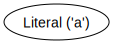


--- NFA noch nicht erstellt (keine build_func angegeben) ---


In [3]:
regex_visualisieren("a")

### Das Bauprinzip für Literale

Für ein Literal `a` erstellen wir zwei Zustände: einen Startzustand und einen akzeptierenden Endzustand. Wir verbinden sie mit einem Pfeil, der mit dem Zeichen `a` beschriftet ist.

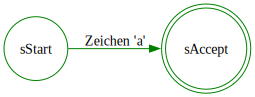

In [4]:
display(graphviz.Source(
    'digraph { rankdir=LR; node [shape=circle]; sStart [label="sStart", color=green]; sAccept [label="sAccept", shape="doublecircle" color=green]; sStart -> sAccept [label="Zeichen \'a\'", color=green]; }'))

Zunächst bereiten wir ein paar Funktionen vor, die wir später aufrufen werden:

- `neuer_zustand`: Wird mit dem `state_counter` aufgerufen, und erstellt einen neuen Zustand `sN`, wobei `N` der aktuelle Zählerwert ist.
- `nfa_bauen`: Erlaubt es uns einen Teil-NFA zusammen zu stellen. Das darin aufgerufene `transformationen`-Dictionary werden wir Stück für Stück um die Implementierung erweitern.

In [5]:
def neuer_zustand(counter):
    name = f"s{counter[0]}"
    counter[0] += 1
    return State(name)


transformationen = {}


def nfa_bauen(node, state_counter):
    if node is None:
        state = neuer_zustand(state_counter)
        return NFA(state, state)

    transformiert = None

    for t, func in transformationen.items():
        if isinstance(node, t):
            transformiert = func(node, state_counter)
            break

    if transformiert is None:
        raise TypeError(f"Diesen Knotentyp können wir noch nicht verarbeiten: {type(node)}")
    else:
        return transformiert

**Deine Aufgabe**: Implementiere den ersten Teil von `nfa_bauen`. Wir fangen nur mit `Literal` an.

Muster: a

--- AST (Strukturbaum) ---


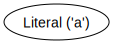


--- NFA (Automat) ---


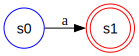

In [6]:
def literal_transformieren(node, state_counter=None):
    # TODO: Implementiere die Konstruktion für den Teil-NFA für ein Literal
    # 1. Neuen Startzustand "start" erstellen
    # 2. Neuen Endzustand "accept" erstellen
    # 3. Übergang von start zu accept mit Zeichen `node.char` erstellen
    # 4. Teil-NFA zurückgeben
    pass


transformationen[Literal] = literal_transformieren

# Teste dein Ergebnis:
regex_visualisieren("a", build_func=nfa_bauen)

**Tipp:** Mit den Funktionen `regex_test` und `regex_find` kannst du deinen Automaten direkt an Beispielen ausprobieren:

In [7]:
result = regex_test("a", "a", parse_func=regex_parsen, build_func=nfa_bauen)
print("Ganzer Text passt:", result)
regex_find("a", "blablubb", parse_func=regex_parsen, build_func=nfa_bauen)
print("Im Text enthalten:", result)

Ganzer Text passt: True
Im Text enthalten: True


## Schritt 2: Konkatenation (Aneinanderreihen) [Slide 17]

Wenn wir zwei Zeichen hintereinander haben (z.B. `ab`), nennt man das **Konkatenation**. Im AST siehst du dann einen `Concatenation`-Knoten, der zwei Unterbäume hat: Den Teilbaum für das Literal `a` (links) und den Teilbaum für das Literal `b` (rechts).

Schau dir den AST für `ab` an:

Muster: ab

--- AST (Strukturbaum) ---


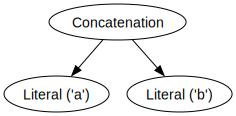


--- NFA noch nicht erstellt (keine build_func angegeben) ---


In [8]:
regex_visualisieren("ab")

### Das Bauprinzip für Konkatenation

Um `AB` zu bauen, bauen wir erst den Automaten für `A` und den für `B`. Dann verbinden wir den Endzustand von `A` mit dem Startzustand von `B` über einen sogenannten **Epsilon-Übergang** (ein ε-Übergang, der kein Zeichen benötigt, wird in unserem Code durch `None` dargestellt).

In Grün sind die neu hinzugekommenen Zustände und Übergänge hervorgehoben:

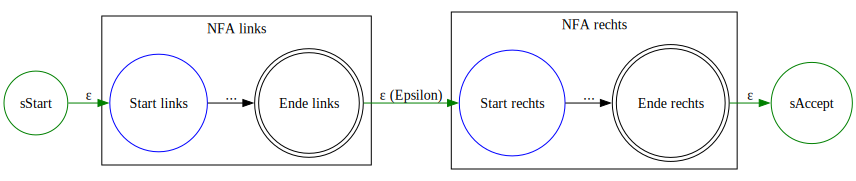

In [9]:
display(graphviz.Source(
    'digraph { rankdir=LR; node [shape=circle]; sStart [label="sStart", color=green]; sAccept [label="sAccept", color=green]; subgraph cluster_left { label="NFA links"; sL0 [label="Start links", color=blue]; sL1 [label="Ende links", shape=doublecircle]; sL0 -> sL1 [label="..."]; } subgraph cluster_right { label="NFA rechts"; sR0 [label="Start rechts", color=blue]; sR1 [label="Ende rechts", shape=doublecircle]; sR0 -> sR1 [label="..."]; } sStart -> sL0 [label="ε", color=green]; sL1 -> sR0 [label="ε (Epsilon)", color=green]; sR1 -> sAccept [label="ε", color=green]; }'))

**Deine Aufgabe**: Erweitere `nfa_bauen`, um `Concatenation` zu unterstützen.

Muster: ab

--- AST (Strukturbaum) ---


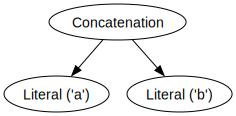


--- NFA (Automat) ---


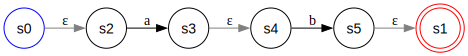

In [10]:
def concatenation_transformieren(node, state_counter):
    # TODO Implementiere die Konstruktion für den Teilbaum der Konkatenation:
    # 1. Start und Endzustand für den Teil-NFA definieren
    # 2. Linken Teilbaum bauen (node.left)
    # 3. Rechten Teilbaum bauen (node.right)
    # 4. Den Endzustand von links (links.accept_state) mit dem Startzustand von rechts (rechts.start_state) verbinden
    # 5. Startzustand mit Startzustand von links verbinden
    # 6. Endzustand von rechts mit Endzustand verbinden
    # 7. Teil-NFA zurückgeben
    pass


transformationen[Concatenation] = concatenation_transformieren

# Teste dein Ergebnis:
regex_visualisieren("ab", build_func=nfa_bauen)

**Tipp**: Um den Automaten kleiner zu halten, kann man auch den Concatenation-Startzustand mit dem linken Startzustand, und den rechten Endzustand mit dem Concatenation-Endzustand zusammenlegen, und sich so den zusätzlichen `ε`-Übergang sparen.

## Schritt 3: Alternation (Oder / Auswahl) [Slide 18]

Mit dem Zeichen `|` können wir sagen: "Entweder das oder das" (z.B. `a|b`). Im AST erscheint dies als `Alternation`-Knoten.

Schau dir den AST für `a|b` an:

Muster: a|b

--- AST (Strukturbaum) ---


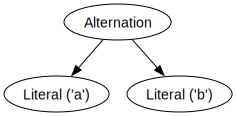


--- NFA noch nicht erstellt (keine build_func angegeben) ---


In [11]:
regex_visualisieren("a|b")

### Das Bauprinzip für Alternation

Für `A|B` erstellen wir einen neuen Startzustand, von dem aus wir per Epsilon-Übergang entweder zum Start von `A` oder zum Start von `B` springen können. Ebenso führen die Endzustände von `A` und `B` per Epsilon-Übergang zu einem gemeinsamen neuen Endzustand.

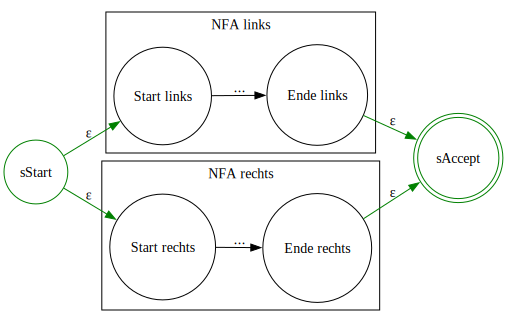

In [12]:
display(graphviz.Source(
    'digraph { rankdir=LR; node [shape=circle]; sStart [label="sStart", color=green]; sAccept [label="sAccept", shape=doublecircle, color=green]; subgraph cluster_left { label="NFA links"; sL0 [label="Start links"]; sL1 [label="Ende links"]; sL0 -> sL1 [label="..."]; } subgraph cluster_right { label="NFA rechts"; sR0 [label="Start rechts"]; sR1 [label="Ende rechts"]; sR0 -> sR1 [label="..."]; } sStart -> sL0 [label="ε", color=green]; sStart -> sR0 [label="ε", color=green]; sL1 -> sAccept [label="ε", color=green]; sR1 -> sAccept [label="ε", color=green]; }'))

**Deine Aufgabe**: Erweitere `nfa_bauen` um `Alternation`.

Muster: a|b

--- AST (Strukturbaum) ---


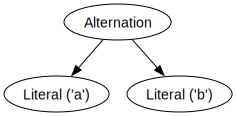


--- NFA (Automat) ---


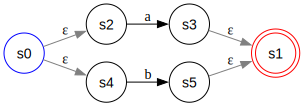

In [13]:
def alternation_transformieren(node, state_counter):
    # TODO Implementiere die Konstruktion für Alternation
    # 1. Start- und Endzustand für den Alternation-NFA definieren
    # 2. Teil-NFAs für die beiden Pfade node.left und node.right bauen
    # 3. Startzustand mit beiden Teil-NFAs verbinden
    # 4. Teil-NFAs mit dem Endzustand verbinden
    # 5. Alternation-NFA zurückgeben
    pass


transformationen[Alternation] = alternation_transformieren

# Teste dein Ergebnis:
regex_visualisieren("a|b", build_func=nfa_bauen)

## Schritt 4: Der Kleene-Stern (Wiederholung) [Slide 19]

Der Stern `*` bedeutet: "Nullmal oder beliebig oft". Im AST ist das ein `Star`-Knoten, der einen anderen Ausdruck umschließt.

Noch wird der Stern von unserem Parser aber als `Literal` interpretiert:

Muster: a*

--- AST (Strukturbaum) ---


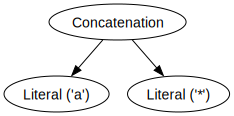


--- NFA (Automat) ---


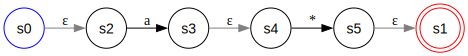

In [14]:
regex_visualisieren("a*", build_func=nfa_bauen)

**Vorbereitung:** Erstmal passen wir also unseren Parser an.

Wir erstellen einen neuen unary-Operator `Star` und hängen ihn in den Parser ein:

In [15]:
# Wir definieren den AST-Knoten für Star:
@dataclass
class Star(UnaryOp):
    pass


# Wir hängen den Stern als Postfix-Handler ein:
def regex_parsen(pattern):
    parser = RegexParser(pattern)
    parser.postfix_handlers['*'] = lambda node: Star(node)
    return parser.parse()

### Das Bauprinzip für den Stern

Für `a*` brauchen wir einen neuen Start- und Endzustand, um zwei Dinge zu ermöglichen:
1. **Wiederholung**: Der Endzustand von führt zurück zum Start.
2. **Überspringen**: Der Startzustand kann direkt zum Endzustand springen (wenn das Zeichen 0-mal vorkommt).

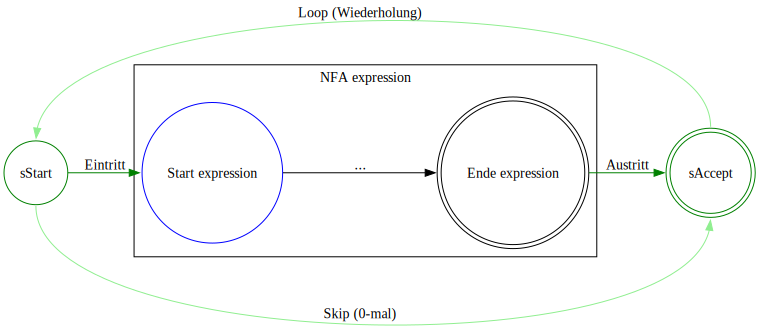

In [16]:
display(graphviz.Source(
    'digraph { rankdir=LR; node [shape=circle]; sStart [label="sStart", color=green]; sAccept [label="sAccept", shape=doublecircle, color=green]; subgraph cluster_expr { label="NFA expression"; sL0 [label="Start expression", color=blue]; sL1 [label="Ende expression", shape=doublecircle]; sL0 -> sL1 [label="..."]; } sStart:e -> sL0:w [label="Eintritt", color=green]; sAccept:n -> sStart:n [label="Loop (Wiederholung)", color=lightgreen]; sL1 -> sAccept [label="Austritt", color=green]; sStart:s -> sAccept:s [label="Skip (0-mal)", color=lightgreen]; }'))

**Deine Aufgabe**: Vervollständige `nfa_bauen` für den `Star`-Knoten.

Muster: a*

--- AST (Strukturbaum) ---


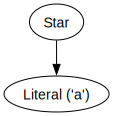


--- NFA (Automat) ---


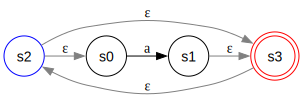

In [17]:
def star_transformieren(node, state_counter):
    # TODO: Implementiere die Konstruktion für Star
    # Du bist auf dich allein gestellt! :)
    pass


transformationen[Star] = star_transformieren

# Teste dein Ergebnis:
regex_visualisieren("a*", parse_func=regex_parsen, build_func=nfa_bauen)

## Finale Tests

Jetzt, wo du alle Grundbausteine hast, testen wir deinen Automaten mit verschiedenen Mustern und Texten.

In [18]:
def regex_testen(pattern, text, expected):
    result = regex_test(pattern, text, parse_func=regex_parsen, build_func=nfa_bauen)
    print(f"Pattern: {pattern}, Text: {text}, Erwartet: {expected}, Ergebnis: {result}")
    assert result == expected


regex_testen("a", "a", True)
regex_testen("a", "b", False)
regex_testen("a|b", "a", True)
regex_testen("a|", "a", True)
regex_testen("a|b", "b", True)
regex_testen("a|b", "c", False)
regex_testen("a*", "", True)
regex_testen("a*", "aaaa", True)
regex_testen("a*", "b", False)
regex_testen("ab", "ab", True)
regex_testen("ab", "a", False)
regex_testen("(a|b)*c", "ababac", True)
regex_testen("(a|b)*c", "ababc", True)
regex_testen("(a|b)*c", "abab", False)
print("\nAlle Tests bestanden! Super gemacht!")

Pattern: a, Text: a, Erwartet: True, Ergebnis: True
Pattern: a, Text: b, Erwartet: False, Ergebnis: False
Pattern: a|b, Text: a, Erwartet: True, Ergebnis: True
Pattern: a|, Text: a, Erwartet: True, Ergebnis: True
Pattern: a|b, Text: b, Erwartet: True, Ergebnis: True
Pattern: a|b, Text: c, Erwartet: False, Ergebnis: False
Pattern: a*, Text: , Erwartet: True, Ergebnis: True
Pattern: a*, Text: aaaa, Erwartet: True, Ergebnis: True
Pattern: a*, Text: b, Erwartet: False, Ergebnis: False
Pattern: ab, Text: ab, Erwartet: True, Ergebnis: True
Pattern: ab, Text: a, Erwartet: False, Ergebnis: False
Pattern: (a|b)*c, Text: ababac, Erwartet: True, Ergebnis: True
Pattern: (a|b)*c, Text: ababc, Erwartet: True, Ergebnis: True
Pattern: (a|b)*c, Text: abab, Erwartet: False, Ergebnis: False

Alle Tests bestanden! Super gemacht!


## Alles zusammen [Slide 20]

Pattern: (a|b)c*, Text: acc, Erwartet: True, Ergebnis: True
Pattern: (a|b)c*, Text: ac, Erwartet: True, Ergebnis: True
Pattern: (a|b)c*, Text: a, Erwartet: True, Ergebnis: True
Pattern: (a|b)c*, Text: bcc, Erwartet: True, Ergebnis: True
Pattern: (a|b)c*, Text: bc, Erwartet: True, Ergebnis: True
Pattern: (a|b)c*, Text: b, Erwartet: True, Ergebnis: True
Muster: (a|b)c*

--- AST (Strukturbaum) ---


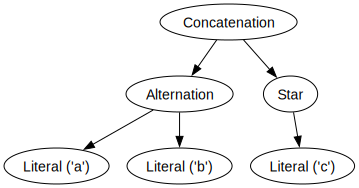


--- NFA (Automat) ---


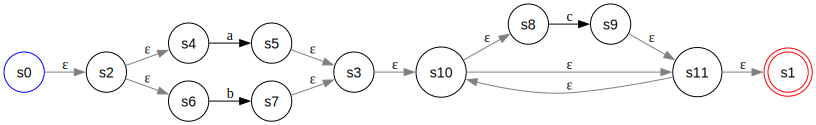

In [19]:
regex_testen("(a|b)c*", "acc", True)
regex_testen("(a|b)c*", "ac", True)
regex_testen("(a|b)c*", "a", True)
regex_testen("(a|b)c*", "bcc", True)
regex_testen("(a|b)c*", "bc", True)
regex_testen("(a|b)c*", "b", True)
regex_visualisieren("(a|b)c*", build_func=nfa_bauen, parse_func=regex_parsen)

## Bonus: Den Parser erweitern

Unser Parser ist so gebaut, dass du ganz einfach neue Symbole hinzufügen kannst, ohne den Kerncode ändern zu müssen. Wir nutzen dafür die `postfix_handlers`.

### Aufgabe: Den `?` (Optional) Operator hinzufügen

Das Zeichen `?` bedeutet "null oder einmal".
1. Wir erstellen einen `Optional`-Knoten für unseren AST.
2. Wir sagen dem Parser, dass er das Zeichen `?` als `Optional`-Knoten behandeln soll.
3. Wir erweitern die NFA-Logik.

**Tipp 1**: Ein optionales `A?` ist fast wie `A*`, nur dass es keine Schleife zurück zum Start von `A` gibt.
**Tipp 2**: Ein optionales `A?` ist das selbe wie `(A|ε)`

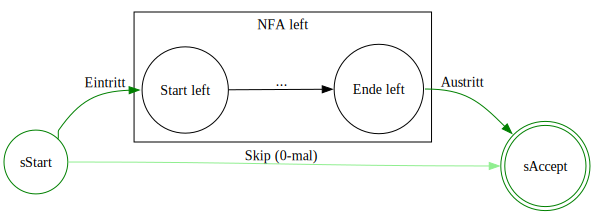

In [20]:
display(graphviz.Source(
    'digraph { rankdir=LR; node [shape=circle]; sStart [label="sStart", color=green]; sAccept [label="sAccept", shape=doublecircle, color=green]; subgraph cluster_A { label="NFA left"; sA0 [label="Start left"]; sA1 [label="Ende left"]; sA0 -> sA1 [label="..."]; } sStart:ne -> sA0:w [label="Eintritt", color=green]; sA1:e -> sAccept:nw [label="Austritt", color=green]; sStart:e -> sAccept:w [label="Skip (0-mal)", color=lightgreen]; }'))

Ohne Änderung an unserem Parser wird `?` einfach als Literal interpretiert:

Muster: a?b

--- AST (Strukturbaum) ---


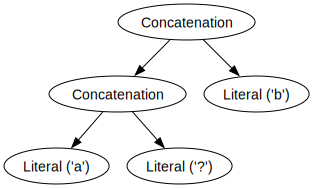


--- NFA noch nicht erstellt (keine build_func angegeben) ---


In [21]:
regex_visualisieren("a?b")

**Vorbereitung:** Auch hier erweitern wir also erstmal unseren Parser um das `?`-Zeichen als Postfix-Operator:

In [22]:
def regex_parsen(pattern):
    parser = RegexParser(pattern)
    parser.postfix_handlers['*'] = lambda node: Star(node)
    # TODO: Parser für '?' erweitern
    return parser.parse()

Und sehen nun auch den neuen Knoten in unserem AST:

Muster: a?b(c|)(|d)

--- AST (Strukturbaum) ---


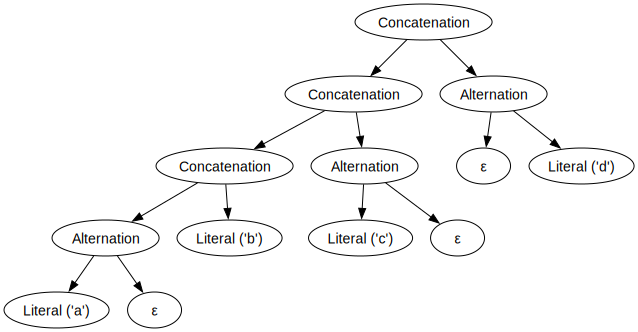


--- NFA noch nicht erstellt (keine build_func angegeben) ---


In [23]:
regex_visualisieren("a?b(c|)(|d)", parse_func=regex_parsen)

Fehlt nur noch die Implementierung in unserer Transformation:

Muster: a?b

--- AST (Strukturbaum) ---


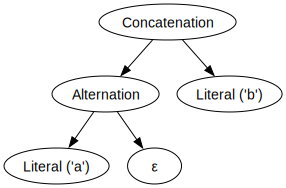


--- NFA (Automat) ---


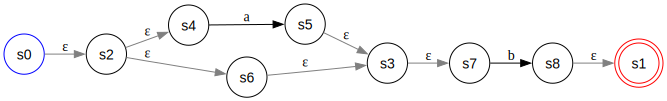

In [24]:
# Testen
regex_visualisieren("a?b", parse_func=regex_parsen, build_func=nfa_bauen)

In [25]:
# TODO: Spielwiese

# Wenn du es bis hier geschafft hast: Wie wäre es damit, '+' zu implementieren?